In [17]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import networkx as nx
import random
from itertools import combinations



df_heroes = pd.read_csv('../FASERIP.csv')

In [18]:
df_heroes['Health'] = df_heroes['F'] + df_heroes['A'] + df_heroes['S'] + df_heroes['E']
df_heroes['Karma'] = df_heroes['R'] + df_heroes['I'] + df_heroes['P']



In [19]:

def melee_attack(attacker, defender):
    fighting_rank = attacker['F_rank']
    thresholds = universal_table[fighting_rank]
    roll = random.randint(1, 100)
    
    if roll >= thresholds['red']:
        return 'Red', attacker['S']
    elif roll >= thresholds['yellow']:
        return 'Yellow', attacker['S']
    elif roll >= thresholds['green']:
        return 'Green', attacker['S']
    else:
        return 'White', 0

In [20]:
def fight_log(hero_a, hero_b):
    health_a = hero_a['Health']
    health_b = hero_b['Health']
    log = [{'round': 0, hero_a['character']: health_a, hero_b['character']: health_b}]
    round_num = 0
    
    while health_a > 0 and health_b > 0:
        round_num += 1
        
        color, damage = melee_attack(hero_a, hero_b)
        damage = max(damage - hero_b['Armour'], 0)
        health_b -= damage
        
        if health_b <= 0:
            log.append({'round': round_num, hero_a['character']: health_a, hero_b['character']: max(health_b, 0)})
            return hero_a['character'], log
        
        color, damage = melee_attack(hero_b, hero_a)
        damage = max(damage - hero_a['Armour'], 0)
        health_a -= damage
        
        log.append({'round': round_num, hero_a['character']: max(health_a, 0), hero_b['character']: max(health_b, 0)})
        
        if health_a <= 0:
            return hero_b['character'], log
    
    return 'Draw', log

In [21]:
def fight(hero_a, hero_b, max_rounds=200):
    health_a = hero_a['Health']
    health_b = hero_b['Health']
    
    for _ in range(max_rounds):
        color, damage = melee_attack(hero_a, hero_b)
        damage = max(damage - hero_b['Armour'], 0)
        health_b -= damage
        if health_b <= 0:
            return hero_a['character']
        
        color, damage = melee_attack(hero_b, hero_a)
        damage = max(damage - hero_a['Armour'], 0)
        health_a -= damage
        if health_a <= 0:
            return hero_b['character']
    
    return 'Draw'

In [22]:
universal_table = {
    'Shift 0':    {'green': 65, 'yellow': 95, 'red': 100},
    'Feeble':     {'green': 60, 'yellow': 90, 'red': 100},
    'Poor':       {'green': 55, 'yellow': 85, 'red': 100},
    'Typical':    {'green': 50, 'yellow': 80, 'red': 97},
    'Good':       {'green': 45, 'yellow': 75, 'red': 95},
    'Excellent':  {'green': 40, 'yellow': 70, 'red': 91},
    'Remarkable': {'green': 35, 'yellow': 65, 'red': 86},
    'Incredible': {'green': 30, 'yellow': 60, 'red': 81},
    'Amazing':    {'green': 26, 'yellow': 56, 'red': 76},
    'Monstrous':  {'green': 21, 'yellow': 51, 'red': 86},
    'Unearthly':  {'green': 16, 'yellow': 46, 'red': 86},
    'Shift X':    {'green': 11, 'yellow': 41, 'red': 81},
    'Shift Y':    {'green': 6,  'yellow': 36, 'red': 76},
    'Shift Z':    {'green': 4,  'yellow': 31, 'red': 71},
    'Class 1000': {'green': 2,  'yellow': 36, 'red': 76},
    'Class 3000': {'green': 2,  'yellow': 31, 'red': 71},
    'Class 5000': {'green': 2,  'yellow': 26, 'red': 66},
    'Beyond':     {'green': 2,  'yellow': 21, 'red': 61},
}


In [23]:
def feat_check(rank, roll):
    t = universal_table[rank]
    if roll >= t['red']:   return 'Red'
    if roll >= t['yellow']: return 'Yellow'
    if roll >= t['green']:  return 'Green'
    return 'White'

def num_to_rank(val):
    if val <= 0:  return 'Shift 0'
    if val <= 2:  return 'Feeble'
    if val <= 4:  return 'Poor'
    if val <= 7:  return 'Typical'
    if val <= 15: return 'Good'
    if val <= 25: return 'Excellent'
    if val <= 35: return 'Remarkable'
    if val <= 45: return 'Incredible'
    if val <= 62: return 'Amazing'
    if val <= 87: return 'Monstrous'
    if val <= 125: return 'Unearthly'
    if val <= 175: return 'Shift X'
    if val <= 350: return 'Shift Y'
    if val <= 750: return 'Shift Z'
    if val <= 2000: return 'Class 1000'
    if val <= 4000: return 'Class 3000'
    if val <= 5000: return 'Class 5000'
    return 'Beyond'

In [24]:
stat_cols = ['F', 'A', 'S', 'E', 'R', 'I', 'P']

for col in stat_cols:
    df_heroes[col + '_rank'] = df_heroes[col].apply(num_to_rank)

In [25]:
df_heroes[df_heroes['character'] == 'Spider-man'][['character'] + [c + '_rank' for c in stat_cols]]

,character,F_rank,A_rank,S_rank,E_rank,R_rank,I_rank,P_rank
35,Spider-man,Remarkable,Amazing,Incredible,Incredible,Excellent,Good,Incredible


In [26]:
hero_a = df_heroes[df_heroes['character'] == 'Black Panther'].iloc[0]
hero_b = df_heroes[df_heroes['character'] == 'Spider-man'].iloc[0]

results = [fight(hero_a, hero_b) for _ in range(1000)]
print(pd.Series(results).value_counts())

Spider-man       940
Black Panther     60
Name: count, dtype: int64


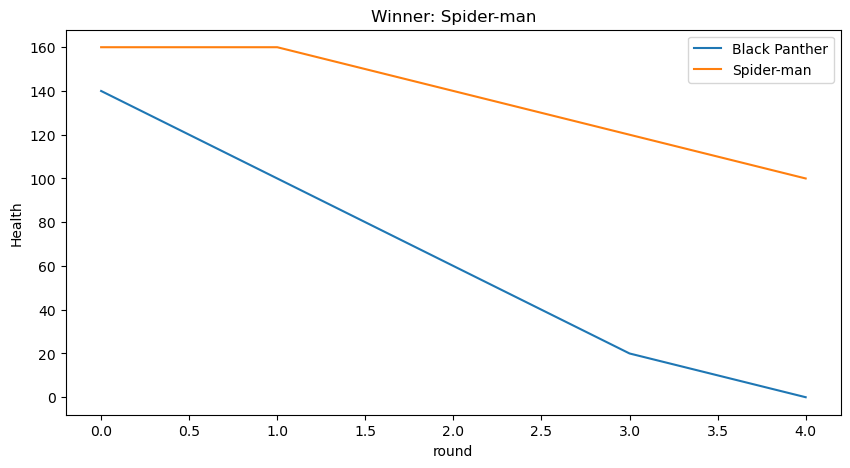

Spider-man


In [27]:
hero_a = df_heroes[df_heroes['character'] == 'Black Panther'].iloc[0]
hero_b = df_heroes[df_heroes['character'] == 'Spider-man'].iloc[0]

winner, log = fight_log(hero_a, hero_b)
df_log = pd.DataFrame(log)
df_log.plot(x='round', figsize=(10,5), title=f'Winner: {winner}')
plt.ylabel('Health')
plt.show()
print(winner)

In [28]:
hero_a = df_heroes[df_heroes['character'] == 'Thing'].iloc[0]
hero_b = df_heroes[df_heroes['character'] == 'Colossus'].iloc[0]

print(f"Thing:    F={hero_a['F']} S={hero_a['S']} H={hero_a['Health']} A={hero_a['Armour']} Frank={hero_a['F_rank']}")
print(f"Colossus: F={hero_b['F']} S={hero_b['S']} H={hero_b['Health']} A={hero_b['Armour']} Frank={hero_b['F_rank']}")
print(f"Thing damage per hit: {max(hero_a['S'] - hero_b['Armour'], 0)}")
print(f"Colossus damage per hit: {max(hero_b['S'] - hero_a['Armour'], 0)}")

Thing:    F=40 S=75 H=200 A=40 Frank=Incredible
Colossus: F=10 S=75 H=145 A=50 Frank=Good
Thing damage per hit: 25
Colossus damage per hit: 35


In [29]:
print(len(df_heroes))

98


In [30]:
results = []
heroes = df_heroes.to_dict('records')

for i, j in combinations(range(len(heroes)), 2):
    wins = {heroes[i]['character']: 0, heroes[j]['character']: 0, 'Draw': 0}
    for _ in range(1000):
        winner = fight(heroes[i], heroes[j])
        wins[winner] += 1
    results.append({
        'fighter_a': heroes[i]['character'],
        'fighter_b': heroes[j]['character'],
        'wins_a': wins[heroes[i]['character']],
        'wins_b': wins[heroes[j]['character']],
        'draws': wins['Draw']
    })
    
df_results = pd.DataFrame(results)

In [31]:
df_results.head

<bound method NDFrame.head of          fighter_a        fighter_b  wins_a  wins_b  draws
0            Angel           Aurora     996       4      0
1            Angel            Beast       0    1000      0
2            Angel     Black Knight       0    1000      0
3            Angel              Box       0    1000      0
4            Angel  Captain America       0    1000      0
...            ...              ...     ...     ...    ...
4748           Fly     Green Goblin    1000       0      0
4749           Fly        Hydro man       0    1000      0
4750     Gladiator     Green Goblin    1000       0      0
4751     Gladiator        Hydro man       0    1000      0
4752  Green Goblin        Hydro man       0    1000      0

[4753 rows x 5 columns]>

In [32]:
wins_as_a = df_results.groupby('fighter_a')['wins_a'].sum()
wins_as_b = df_results.groupby('fighter_b')['wins_b'].sum()

total_wins = wins_as_a.add(wins_as_b, fill_value=0).sort_values(ascending=False)
print(total_wins.head(20))

Silver surfer     95974.0
Hulk              94958.0
Hercules          93356.0
Thor              92930.0
Wonder Man        92311.0
Box               90201.0
Thing             88545.0
Colossus          87813.0
She-Hulk          87457.0
Ultron            83000.0
Sub-Mariner       81995.0
Firelord          79237.0
Crimson Dynamo    78885.0
Titanium Man      77565.0
Annihulus         76103.0
Ms Marvel         75113.0
Rogue             73985.0
Stingray          71946.0
Loki              70657.0
Iron man          69368.0
dtype: float64


In [33]:
hulk_losses_a = df_results[(df_results['fighter_a'] == 'Hulk') & (df_results['wins_b'] > df_results['wins_a'])]
hulk_losses_b = df_results[(df_results['fighter_b'] == 'Hulk') & (df_results['wins_a'] > df_results['wins_b'])]

print("Characters who beat Hulk:")
for _, row in hulk_losses_a.iterrows():
    print(f"  {row['fighter_b']}: {row['wins_b']}-{row['wins_a']}")
for _, row in hulk_losses_b.iterrows():
    print(f"  {row['fighter_a']}: {row['wins_a']}-{row['wins_b']}")

Characters who beat Hulk:
  Silver surfer: 974-26


In [34]:
df_results['difference'] = abs(df_results['wins_a']-df_results['wins_b'])


In [35]:


sorted_df_asc = df_results.sort_values(by='difference')
filtered_and_sorted_df = sorted_df_asc[sorted_df_asc['draws'] <= 500]
filtered_and_sorted_df.head(40)


,fighter_a,fighter_b,wins_a,wins_b,draws,difference
946,Dagger,Shaman,501,499,0,2
230,Beast,Tigra,498,502,0,4
3593,Boomerang,Red Ghost,497,503,0,6
859,Cyclops,Shaman,495,505,0,10
2453,Puck,Moondragon,494,506,0,12
2451,Puck,Falcon,494,506,0,12
4413,Vulture,Medusa,484,516,0,32
2384,Professor X,Hellcat,479,521,0,42
2226,Northstar,Kingpin,521,479,0,42
2135,Nightcrawler,Storm,525,475,0,50
